In [1]:
from INEGIpy import DENUE
import pandas as pd
import geopandas as gpd
import os

In [2]:
token = 'd98d108f-dded-4b04-b1ce-7b2b990de870'
denue = DENUE(token)

In [3]:
cdit = gpd.read_file(os.path.join('..', 'datos', '00_insumos', 'ubicacion_cditvallejo.gpkg'))
cdit.head()

,nombre,geometry
0,Centro de Desarrollo e Innovación Vallejo-i,POINT (480915.239 2154853.577)


<Axes: >

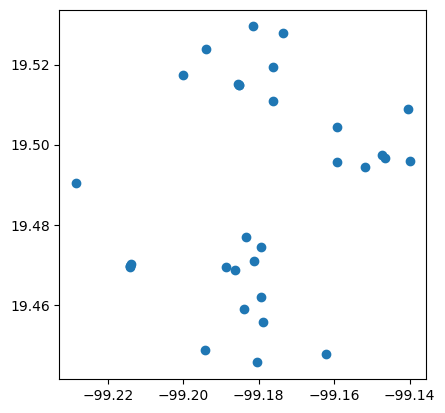

In [4]:

# Reproyectamos a WGS84 para obtener lat/lon geográficas que requiere la API
cdit_geo = cdit.to_crs(4326)
lat = cdit_geo.geometry.y.iloc[0]
lon = cdit_geo.geometry.x.iloc[0]

# La API del DENUE acepta un máximo de 5000 metros de radio
ue = denue.Buscar(
    'Servicios educativos',
    latitud=lat,
    longitud=lon,
    distancia=4999)
ue.plot()


In [6]:
ue['Clase_actividad'].value_counts()

Clase_actividad
Otros servicios educativos proporcionados por el sector privado                                     13
Escuelas de educación primaria del sector público                                                    8
Escuelas de educación preescolar del sector público                                                  4
Otros servicios educativos proporcionados por el sector público                                      2
Servicios de profesores particulares                                                                 1
Escuelas del sector público de educación para necesidades especiales                                 1
Escuelas del sector privado que combinan diversos niveles de educación                               1
Centros del sector público dedicados a la atención y cuidado diurno de ancianos y discapacitados     1
Escuelas de educación superior del sector público                                                    1
Name: count, dtype: int64

In [ ]:
ue